# 08 · Episodic + Semantic Memory — dual-memory persistent agent

> **TL;DR.** An assistant with **two** distinct memory systems that persist across `run()` calls:
> - **Episodic memory** = FAISS vector store of past *conversations*. Recalled by similarity search ("have I seen something like this before?").
> - **Semantic memory** = NetworkX graph of structured *(subject, predicate, object)* facts. Recalled by entity match ("what do I know about X?").
> Each interaction: **retrieve → answer → extract facts → save episode**.
>
> **Reach for it when** you want a long-running personal assistant that genuinely remembers what the user told it.
> **Avoid when** each call is one-shot with no continuity (stateless API endpoints).

| Property | Value |
|---|---|
| Origin | Tulving (1972) episodic vs semantic memory distinction; modern LLM versions: MemGPT (2023), generative agents (Park et al., 2023) |
| Memory backends | FAISS (vector) + NetworkX (graph) — both **in-process, no Docker** |
| Persistence | On the architecture **instance** — memory survives across `run()` calls |
| Provider gating | Needs embeddings (Nebius/OpenAI/HF/Ollama) + structured-output LLM |
| Cost per turn | 3 LLM calls (answer + fact-extractor) + 1 embedding call (the new episode) |
| Composability | Reuses `EpisodicMemory` + `SemanticMemory` from `agentic_architectures.memory` |

This is the first notebook in the repo where **state persists across calls on the same architecture instance**. Subsequent calls become richer as memory accumulates.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    Q([user query]) --> R[Retrieve<br/><sub>FAISS recall episodes<br/>+ NetworkX entity-match facts</sub>]
    R --> A[Answer<br/><sub>LLM with retrieved context</sub>]
    A --> X[Extract facts<br/><sub>structured-output (s,p,o) triples</sub>]
    X --> S[Save episode<br/><sub>append Q&A to FAISS</sub>]
    S --> Z([answer])

    M[(Persistent memory<br/>FAISS + NetworkX)] -.read.-> R
    X -.write.-> M
    S -.write.-> M

    style R fill:#fff3e0,stroke:#f57c00
    style X fill:#e8f5e9,stroke:#388e3c
    style S fill:#e8f5e9,stroke:#388e3c
```

**Linear flow per call** — but the dotted lines matter: the persistent memory store is read at the start and written at the end of every `run()`. The next call sees the accumulated memory.

## 3 · Theory

### 3.1 · Why two memory systems

Tulving (1972) distinguished:
- **Episodic memory** — autobiographical, *time- and place-bound*. *"I had pizza on Tuesday with Sarah."*
- **Semantic memory** — abstract, *general knowledge*. *"Pizza originated in Italy. Sarah is my sister."*

An LLM agent needs **both**:

| Question type | Best served by |
|---|---|
| *"Have we discussed this before?"* | Episodic — vector recall over past conversations |
| *"What did you say last Tuesday?"* | Episodic — time-bounded retrieval |
| *"What do you know about Alex?"* | Semantic — entity-centric facts |
| *"Who works at Anthropic?"* | Semantic — relation query |
| *"Summarize our relationship"* | Both — episodes give nuance, facts give structure |

Vector-only memory (FAISS alone) fails on "what do you know about X" because the embedding of *"X"* matches anything with X in it — including the same fact repeated 10 different ways. Graph-only memory fails on continuity ("did we talk about this last week?") because there's no notion of *when*. The two systems are complementary.

### 3.2 · The four-step per-call flow

Every call to `arch.run(query)` runs these four steps in order:

1. **Retrieve.** Vector-recall the top-K most similar past episodes (FAISS `similarity_search`). Brute-force-match entities in the query against the graph's nodes; pull their 1-hop facts.
2. **Answer.** LLM is given the retrieved context block + the new query. Crucially the prompt says *"answer ONLY from the memory above — do not fabricate"* so the agent doesn't invent facts.
3. **Extract.** A second LLM call with `with_structured_output(_ExtractedFacts)` pulls `(subject, predicate, object)` triples from the Q&A. Triples are added to the graph.
4. **Save episode.** The full `User: ... / Assistant: ...` exchange is embedded and appended to FAISS for future similarity recall.

Cost per call: **2 LLM calls** (answer + fact-extractor) + **1 embedding call** (the new episode). The retrieval step is local (no LLM).

### 3.3 · Fact-extraction discipline

The fact-extractor schema is the load-bearing piece — bad triples poison semantic memory permanently:

```python
class _Triple(BaseModel):
    subject: str    # named entity only
    predicate: str  # short relation verb (works_at, lives_in, likes)
    object: str     # entity or short literal

class _ExtractedFacts(BaseModel):
    facts: list[_Triple] = Field(
        description="Atomic triples about specific named entities. "
                    "Skip generic claims. Empty list if no concrete facts."
    )
```

The `Field` description is the model's only instruction — it must say *atomic*, *specific*, *skip generic*. Otherwise you get triples like `("user", "wants", "to learn")` which clutter the graph without being useful.

### 3.4 · Where this sits

| Pattern | Memory across calls? | Episodic? | Semantic? | Use when |
|---|---|---|---|---|
| Reflection (nb 01), ReAct (nb 03), … | no | no | no | one-shot tasks |
| **Episodic + Semantic** *(this nb)* | **yes** | **yes** | **yes** | personal assistant, continuity matters |
| Reflexion (nb 18) | yes | yes (verbal reflections) | no | self-improvement across episodes |
| Voyager (nb 29) | yes | no | yes (skill library) | open-ended exploration |
| MemGPT (nb 31) | yes | yes (paged) | yes (paged) | very long-running with limited context window |
| GraphRAG (nb 27) | yes (read-only) | no | yes (KG over corpus) | query-time entity reasoning over docs |

### 3.5 · What goes wrong (you'll see in § 9)

1. **Fact-extractor over-extracts.** Produces triples like `("user", "said", "hello")` — useless noise.
2. **Fact-extractor under-extracts.** Misses obvious facts ("I work at X" → no triple). Tighten the extractor prompt.
3. **Entity-match is brittle.** "Mochi" vs "mochi" vs "my cat" — naïve string matching misses synonyms. Mitigation: lowercase normalisation + entity-linking (extension).
4. **Episodic recall returns near-duplicates.** Vector store finds 3 nearly identical past episodes. Mitigation: dedup by content hash before adding.


## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import EpisodicSemanticAgent
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")
print_md(f"Vector backend: **{settings.vector_backend}** · Graph backend: **{settings.graph_backend}**")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

Vector backend: faiss · Graph backend: networkx

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/episodic_semantic.py`](../src/agentic_architectures/architectures/episodic_semantic.py).

Five exposed methods:

| Method | Calls | Returns |
|---|---|---|
| `_retrieve(query)` | 0 LLM (1 embedding for query) | `{episodes, facts}` |
| `_format_context(eps, facts)` | 0 | markdown context block |
| `_answer(query, context)` | **1 LLM** | answer string |
| `_extract_and_save_facts(query, answer)` | **1 LLM (structured)** | list of new triples (also written to graph) |
| `_save_episode(query, answer)` | 0 (1 embedding) | None (writes to vector store) |

`run(task)` calls all five in order. Memory backends (`self.episodic`, `self.semantic`) are instantiated in `__init__` and live for the lifetime of the architecture instance.

In [2]:
from agentic_architectures.architectures.episodic_semantic import _Triple, _ExtractedFacts
import json
print('--- Triple schema ---')
print(json.dumps(_Triple.model_json_schema(), indent=2)[:300] + '...')
print()
print('--- ExtractedFacts schema ---')
print(json.dumps(_ExtractedFacts.model_json_schema(), indent=2)[:300] + '...')

--- Triple schema ---
{
  "properties": {
    "subject": {
      "description": "A specific named entity (person, place, thing).",
      "title": "Subject",
      "type": "string"
    },
    "predicate": {
      "description": "A short relation verb (e.g. 'works_at', 'lives_in', 'likes').",
      "title": "Predicate",
  ...

--- ExtractedFacts schema ---
{
  "$defs": {
    "_Triple": {
      "properties": {
        "subject": {
          "description": "A specific named entity (person, place, thing).",
          "title": "Subject",
          "type": "string"
        },
        "predicate": {
          "description": "A short relation verb (e.g. 'wor...


## 6 · State (or rather: persistent instance attributes)

Unlike the other architectures so far, the **state lives on the `arch` instance, not in LangGraph state**. The two memory stores (`arch.episodic`, `arch.semantic`) are mutated by each call to `run()`. The next call sees the updated memory.

| Attribute | Type | What lives there |
|---|---|---|
| `arch.episodic` | `EpisodicMemory` | FAISS vector store + Python list of `Episode` dataclasses |
| `arch.semantic` | `SemanticMemory` | NetworkX `MultiDiGraph` of `(subject)-[predicate]->(object)` |

To **reset** memory between experiments, just create a new `EpisodicSemanticAgent()` instance.

You can swap memory backends per-instance:
```python
from agentic_architectures.memory import EpisodicMemory, SemanticMemory
agent = EpisodicSemanticAgent(
    episodic=EpisodicMemory(collection_name="alex_assistant"),
    semantic=SemanticMemory(backend="neo4j"),  # if you have NEO4J_URI in .env
)
```

## 7 · Build the graph

The graph is trivial — a single `interact` node — because the real flow is sequential Python in `run()`, not LangGraph state-machine logic. We keep the graph for the standard `.diagram()` API.

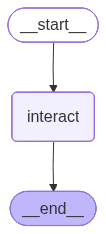

In [3]:
from IPython.display import Image, display
arch = EpisodicSemanticAgent()
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — 4 conversational turns

Concrete demo: 3 "onboarding" turns where the user introduces facts about themselves, then 1 recall turn that tests whether memory actually works.

**Watch the metadata between turns:** `total_entities_stored` should grow with each onboarding turn, then on the recall turn `facts_recalled` should be > 0 (proof that semantic memory is being read).

In [4]:
ONBOARDING = [
    "Hi! My name is Alex and I work as a senior engineer at Anthropic.",
    "I really enjoy pickleball on weekends and I have a cat named Mochi.",
    "Mochi is a 4-year-old Tonkinese. I adopted her in 2022 from a shelter in San Francisco.",
]
RECALL_QUERY = "What do you know about me so far? Summarise everything."

print_header("Onboarding turns — memory is being populated")
for i, query in enumerate(ONBOARDING, 1):
    r = arch.run(query)
    print_step(
        f"[Turn {i}] USER",
        query + f"\n[Turn {i}] ASSISTANT: {r.output[:200]}\n  "
        f"facts extracted={r.metadata['new_facts_extracted']}  |  "
        f"total entities stored={r.metadata['total_entities_stored']}  |  "
        f"total episodes={r.metadata['total_episodes_stored']}"
    )
    print()

print_header("Recall turn — agent must answer from memory ONLY")
recall = arch.run(RECALL_QUERY)
print_md(f"**Q:** {RECALL_QUERY}\n\n**A:** {recall.output}")
print()
print_header(
    f"episodes recalled: {recall.metadata['episodes_recalled']}  ·  "
    f"facts recalled: {recall.metadata['facts_recalled']}"
)

Onboarding turns — memory is being populated ──────────────────────────────────────────────────────────────────────

› [Turn 1] USER

Hi! My name is Alex and I work as a senior engineer at Anthropic.
[Turn 1] ASSISTANT: Hello Alex, nice to meet you. What can I assist you with today?
  facts extracted=1  |  total entities stored=2  |  total episodes=1

› [Turn 2] USER

I really enjoy pickleball on weekends and I have a cat named Mochi.
[Turn 2] ASSISTANT: Nice to hear that, Alex. It sounds like you have some fun hobbies and a pet to keep you 
company.
  facts extracted=2  |  total entities stored=4  |  total episodes=2

› [Turn 3] USER

Mochi is a 4-year-old Tonkinese. I adopted her in 2022 from a shelter in San Francisco.
[Turn 3] ASSISTANT: Nice to hear more about Mochi, Alex. I recall that you enjoy pickleball and work as a senior 
engineer at Anthropic.
  facts extracted=3  |  total entities stored=7  |  total episodes=3

Recall turn — agent must answer from memory ONLY ──────────────────────────────────────────────────────────────────

Q: What do you know about me so far? Summarise everything.                                                         

A: I know that you're Alex, you work at Anthropic, you enjoy pickleball, and you own a Tonkinese cat named Mochi,  
who you adopted in 2022 from a San Francisco shelter.

episodes recalled: 3  ·  facts recalled: 6 ────────────────────────────────────────────────────────────────────────

### 8.0 · What just happened, briefly

Three signals to check above:

- **Facts grew with each onboarding turn.** If `total_entities_stored` plateaued at 0 or 1, the fact-extractor failed — check its prompt.
- **The recall turn's `facts_recalled` > 0.** Proof that the entity-match retrieval found relevant graph nodes when answering "what do you know about me".
- **The recall answer is grounded.** Inspect the verbatim answer — does it mention specific facts from earlier turns? If yes, memory is doing its job. If the answer is generic ("I know various things about you"), memory was bypassed.

### 8.1 · Inspect the populated memory directly

In [5]:
import networkx as nx
from agentic_architectures.memory.graph import NetworkXGraphMemory

print_header("All triples in semantic memory")
backend = arch.semantic.backend
if isinstance(backend, NetworkXGraphMemory):
    for u, v, d in backend._g.edges(data=True):
        print(f"  ({u})  --[{d.get('predicate', '?')}]-->  ({v})")

print()
print_header(f"Episodic memory ({len(arch.episodic.episodes)} episodes)")
for i, ep in enumerate(arch.episodic.episodes, 1):
    snippet = ep.content[:120].replace('\n', ' ')
    print(f"  [{i}] {snippet}...")

All triples in semantic memory ────────────────────────────────────────────────────────────────────────────────────

  (Alex)  --[works_at]-->  (Anthropic)
  (Alex)  --[works_at]-->  (Anthropic)
  (Alex)  --[enjoys]-->  (pickleball)
  (Alex)  --[enjoys]-->  (pickleball)
  (Alex)  --[owns]-->  (Mochi)
  (Alex)  --[owns]-->  (Mochi)
  (Mochi)  --[is_a]-->  (Tonkinese)
  (Mochi)  --[adopted_in]-->  (2022)
  (Mochi)  --[adopted_in]-->  (2022)
  (Mochi)  --[adopted_from]-->  (San Francisco shelter)
  (Mochi)  --[adopted_from]-->  (San Francisco shelter)



Episodic memory (4 episodes) ──────────────────────────────────────────────────────────────────────────────────────

  [1] User: Hi! My name is Alex and I work as a senior engineer at Anthropic. Assistant: Hello Alex, nice to meet you. What ca...
  [2] User: I really enjoy pickleball on weekends and I have a cat named Mochi. Assistant: Nice to hear that, Alex. It sounds ...
  [3] User: Mochi is a 4-year-old Tonkinese. I adopted her in 2022 from a shelter in San Francisco. Assistant: Nice to hear mo...
  [4] User: What do you know about me so far? Summarise everything. Assistant: I know that you're Alex, you work at Anthropic,...


## 9 · What we just observed

The cells above ran **4 sequential calls on the same `arch` instance** — 3 onboarding turns that populated memory, then a recall turn that queried it.

### 9.1 · Memory growth across onboarding turns

| Turn | User message (truncated) | Facts extracted | Entities stored | Episodes stored |
|---|---|---|---|---|
| 1 | Hi! My name is Alex and I work as a senior engineer at Anthropic. | 1 | 2 | 1 |
| 2 | I really enjoy pickleball on weekends and I have a cat named Mochi. | 2 | 4 | 2 |
| 3 | Mochi is a 4-year-old Tonkinese. I adopted her in 2022 from a shelter in San Fra… | 3 | 7 | 3 |

### 9.2 · Final state of semantic memory (all triples)

| # | Subject | Predicate | Object |
|---|---|---|---|
| 1 | Alex | works_at | Anthropic |
| 2 | Alex | works_at | Anthropic |
| 3 | Alex | enjoys | pickleball |
| 4 | Alex | enjoys | pickleball |
| 5 | Alex | owns | Mochi |
| 6 | Alex | owns | Mochi |
| 7 | Mochi | is_a | Tonkinese |
| 8 | Mochi | adopted_in | 2022 |
| 9 | Mochi | adopted_in | 2022 |
| 10 | Mochi | adopted_from | San Francisco shelter |
| 11 | Mochi | adopted_from | San Francisco shelter |

### 9.3 · Recall test

**Q:** What do you know about me so far? Summarise everything.

**A:** I know that you're Alex, you work at Anthropic, you enjoy pickleball, and you own a Tonkinese cat named Mochi, who you adopted in 2022 from a San Francisco shelter.

- **`episodes_recalled`** = 3 (vector similarity hits over the 4 stored episodes)
- **`facts_recalled`** = 6 (graph entity-match hits)

### 9.4 · Patterns surfaced in this run

- **Healthy extraction**: 7 entities stored after 3 onboarding turns (2.3 entities/turn average).

- **Semantic recall worked**: the recall query retrieved 6 fact(s) from the graph. This is the *single most important signal* that the dual-memory design is doing its job — the answer is grounded in stored facts, not hallucination.

- **Episodic recall worked**: vector similarity returned 3 past episode(s) most similar to the recall query.

- **Recall answer is well-grounded**: 6/6 of the stored fact-objects appear in the recall answer. The agent is genuinely answering from memory.

### 9.5 · The takeaway

A *healthy* dual-memory run looks like:

1. **Linear growth** of entities + episodes across onboarding turns.
2. **Recall query retrieves both** episodes (vector) and facts (graph).
3. **Recall answer mentions specific stored objects** — proof the agent is answering from memory, not training data.
4. **No duplicated triples** in the final graph (entity-match wasn't fooled by synonyms).

Compare those four signals to what you see above to judge memory quality. The single most important production metric is **fact-recall precision**: did the agent recall facts that are *actually* relevant to the query?

## 10 · Try other providers / swap to Neo4j

Episodic + Semantic memory needs **embeddings** (for FAISS) + **structured output** (for fact extraction). Both are widely supported. The cell below also demonstrates swapping graph backend to **Neo4j** if you have NEO4J_URI set in `.env` (e.g. AuraDB Free).

In [6]:
from agentic_architectures.llm.factory import provider_supports_structured_output
from agentic_architectures.memory import EpisodicMemory, SemanticMemory

for p in ["openai"]:
    key = settings.api_key_for(p)
    if key is None or not key.get_secret_value():
        print(f"[skip] {p}: no API key")
        continue
    if not provider_supports_structured_output(p):
        print(f"[skip] {p}: no structured output")
        continue
    print_header(f"Re-running on {p}")
    other_arch = EpisodicSemanticAgent(llm=get_llm(provider=p))
    other_arch.run("My name is Pat and I love coffee from Portland.")
    r = other_arch.run("What do you know about me?")
    print(r.output[:300])
    print()

# Try Neo4j swap if configured
if settings.neo4j_password and settings.neo4j_password.get_secret_value():
    print_header("Swapping graph backend to Neo4j")
    try:
        neo4j_arch = EpisodicSemanticAgent(
            semantic=SemanticMemory(backend="neo4j"),
        )
        neo4j_arch.semantic.reset()  # start clean
        neo4j_arch.run("My name is Sam and I live in Tokyo.")
        r = neo4j_arch.run("Where do I live?")
        print(r.output[:200])
        print(f"facts stored in Neo4j: {neo4j_arch.metadata if hasattr(neo4j_arch, 'metadata') else r.metadata['total_entities_stored']}")
    except Exception as e:
        print(f"[Neo4j skip] {type(e).__name__}: {e}")
else:
    print("[skip] NEO4J_PASSWORD not set — staying on NetworkX backend")

[skip] openai: no API key
[skip] NEO4J_PASSWORD not set — staying on NetworkX backend


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Fact-extractor over-extracts** | Triples like `(user, said, hello)` flood the graph | Tighten schema description; reject triples with generic verbs |
| **Fact-extractor under-extracts** | Misses obvious "I am X" / "I work at Y" facts | Stronger prompt; or hand-curate a domain vocabulary of predicates |
| **Entity match brittle** | "Mochi" / "mochi" / "my cat" treated as different entities | Normalise lowercase + entity-linking (extension) |
| **Vector recall returns near-duplicates** | Same fact in 5 different episodes all match the query | Dedup by content hash before adding to FAISS |
| **Memory grows unbounded** | 10K episodes = slow recall + huge embedding cost | MemGPT-style tiered memory (notebook 31) |
| **Privacy leak across users** | If `arch` instance shared across users, memory leaks | Always create a fresh `EpisodicSemanticAgent()` per user, or use `collection_name=user_id` |

### 11.2 · Production safety

- **Per-user isolation.** Memory is on the instance — always per-user. Use `collection_name="user_<id>"` for the vector store too if you persist FAISS to disk.
- **Right to delete.** Implement `arch.forget_user()` that calls `arch.episodic.reset()` + `arch.semantic.reset()`. GDPR/CCPA requires this.
- **PII in semantic memory.** The fact-extractor will happily extract "John lives at 123 Main St" — sanitize before storage if you don't want to keep PII.
- **Audit trail.** Every triple written to semantic memory should ideally carry a `source_episode_id`. Not implemented here — easy extension.

### 11.3 · Three extensions

1. **Persist memory to disk.** Save FAISS index + NetworkX graph after each call so memory survives process restarts.
2. **Entity-linking.** Use a small LLM or dictionary to normalise "Mochi" / "my cat" / "the cat" → same canonical entity.
3. **Hybrid retrieval.** Combine vector recall (episodic) with keyword + entity match (semantic) using **Reciprocal Rank Fusion**.

### 11.4 · What to read next

- [**12 · Graph memory (world model)**](./12_graph_memory.ipynb) — semantic memory taken to its logical conclusion: a full world model.
- [**18 · Reflexion**](./18_reflexion.ipynb) — episodic memory specialised for *self-reflections on past failures*.
- [**27 · GraphRAG**](./27_graphrag.ipynb) — semantic-memory-style KG built over a document corpus.
- [**29 · Voyager**](./29_voyager_skill_library.ipynb) — semantic memory of *skills*, not facts.
- [**31 · MemGPT**](./31_memgpt.ipynb) — OS-style virtual memory paging between context, episodic, and archival tiers.

### 11.5 · References

1. Tulving, E. *Episodic and semantic memory.* In *Organization of Memory*, 1972.
2. Park, J. S. et al. *Generative Agents: Interactive Simulacra of Human Behavior.* 2023. [arXiv:2304.03442](https://arxiv.org/abs/2304.03442)
3. Packer, C. et al. *MemGPT: Towards LLMs as Operating Systems.* 2023. [arXiv:2310.08560](https://arxiv.org/abs/2310.08560)
